# ⚡ EV Charging Station Analytics 
## Advanced Data Visualization using Seaborn


## 📌 Introduction

This project analyzes Electric Vehicle (EV) charging station performance
using advanced data visualization techniques.

The objective is to understand:

• Revenue patterns  
• Charging utilization across cities  
• Customer satisfaction trends  
• Charging efficiency across charger types  

Tools Used:
- Python
- Pandas
- Seaborn
- Matplotlib
- Jupyter Notebook

All charts are made using **Advanced Seaborn + Matplotlib**.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [2]:
df = pd.read_csv("EV_Charging_Station_Analytics.csv")
df.head()

,station_id,city,charger_type,total_sessions,avg_charging_time,energy_delivered_kWh,price_per_kWh,revenue,peak_hours,customer_rating,utilization_rate,day,month
0,STN_001,Pune,Supercharger,197,81,269.68,23.68,36810.69,6-10 PM,2.9,86.28,14,6
1,STN_002,Hyderabad,Slow,170,41,124.75,15.86,13065.09,6-10 AM,4.8,89.58,7,1
2,STN_003,Berlin,Fast,178,77,61.61,11.65,11546.24,6-10 PM,3.5,94.62,17,7
3,STN_004,Sydney,Supercharger,61,77,68.61,15.26,11570.63,6-10 PM,3.5,33.04,12,12
4,STN_005,New York,Fast,118,68,235.61,24.64,37582.99,2-6 PM,3.8,49.72,20,1


In [3]:
df.shape
df.columns
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_id            150 non-null    object 
 1   city                  150 non-null    object 
 2   charger_type          150 non-null    object 
 3   total_sessions        150 non-null    int64  
 4   avg_charging_time     150 non-null    int64  
 5   energy_delivered_kWh  150 non-null    float64
 6   price_per_kWh         150 non-null    float64
 7   revenue               150 non-null    float64
 8   peak_hours            150 non-null    object 
 9   customer_rating       150 non-null    float64
 10  utilization_rate      150 non-null    float64
 11  day                   150 non-null    int64  
 12  month                 150 non-null    int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 15.4+ KB


,total_sessions,avg_charging_time,energy_delivered_kWh,price_per_kWh,revenue,customer_rating,utilization_rate,day,month
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,113.453333,54.986667,175.804267,14.924133,25060.248400,3.770000,60.853800,14.600000,6.460000
std,52.452035,20.735790,83.454406,5.036399,11237.699482,0.751531,22.183876,7.795197,3.553295
min,21.000000,20.000000,33.070000,7.360000,5185.280000,2.500000,20.480000,1.000000,1.000000
25%,67.000000,35.250000,106.180000,10.330000,14972.667500,3.100000,40.497500,8.000000,4.000000
50%,118.000000,54.000000,181.110000,14.275000,25098.310000,3.700000,66.260000,14.000000,6.000000
75%,162.750000,74.000000,251.355000,18.607500,34693.400000,4.400000,79.792500,21.000000,9.750000
max,197.000000,89.000000,299.920000,24.820000,44874.970000,5.000000,94.780000,28.000000,12.000000


In [4]:
## 🔧 Data Cleaning & Feature Engineering

# convert month number to month name
df["month_name"] = pd.to_datetime(df["month"], format="%m").dt.month_name()

# revenue per charging session
df["revenue_per_session"] = df["revenue"] / df["total_sessions"]

# energy delivered per session
df["energy_per_session"] = df["energy_delivered_kWh"] / df["total_sessions"]


##    **  1️. Price Distribution (Histogram + KDE)  **

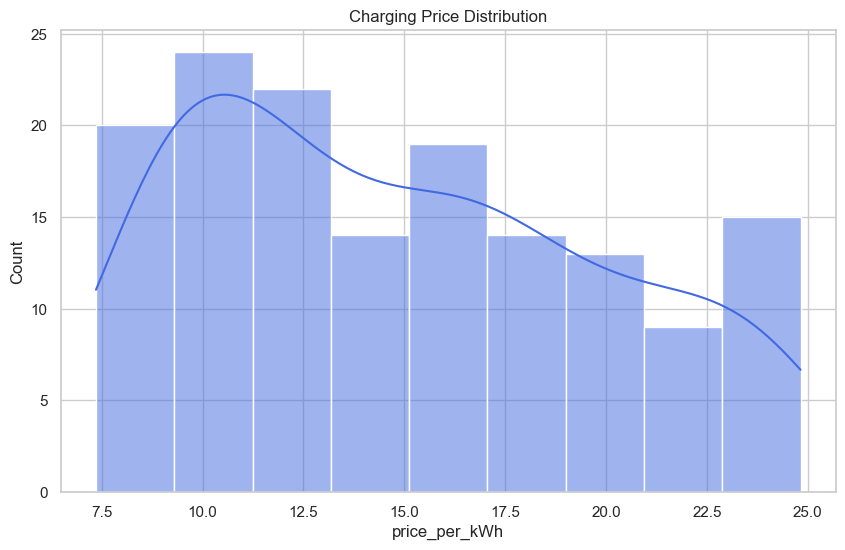

In [5]:
plt.figure()
sns.histplot(df["price_per_kWh"], kde=True, color="royalblue")
plt.title("Charging Price Distribution")
plt.show()


 ##  **  2️. Charger Type vs Revenue — Boxen Plot  **

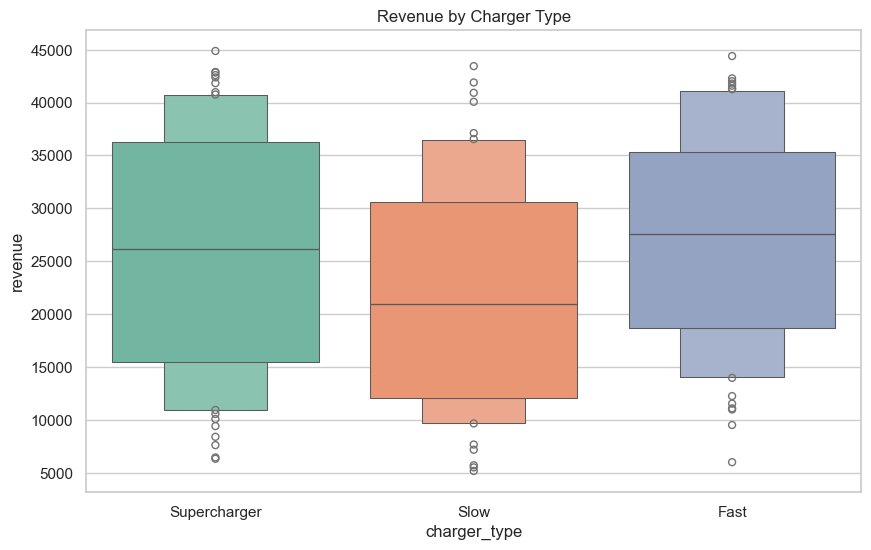

In [6]:
plt.figure()
sns.boxenplot(data=df, x="charger_type", y="revenue", hue="charger_type", palette="Set2", legend=False)
plt.title("Revenue by Charger Type")
plt.show()


##  **  3️. City Utilization — Bar Plot  **

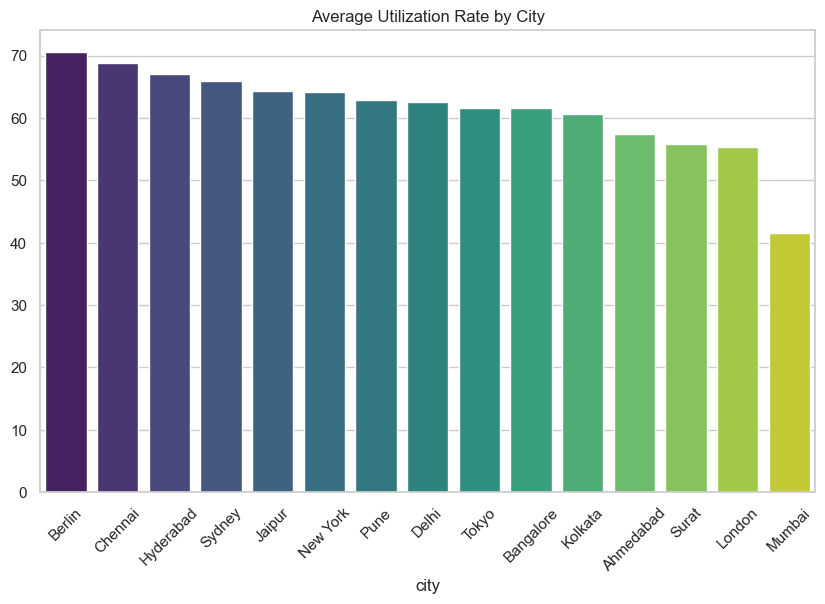

In [7]:
plt.figure()
city_util = df.groupby("city")["utilization_rate"].mean().sort_values(ascending=False)
sns.barplot(x=city_util.index, y=city_util.values, hue=city_util.index, palette="viridis", legend=False)
plt.xticks(rotation=45)
plt.title("Average Utilization Rate by City")
plt.show()


##  **  4. Peak Charging Activity (Heatmap)  **

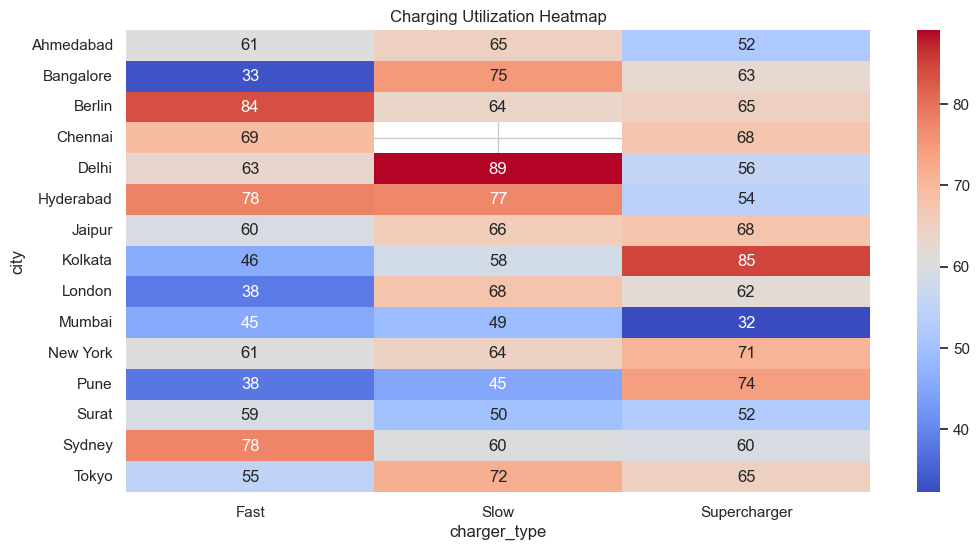

In [8]:
plt.figure(figsize=(12,6))
heat = df.pivot_table(values="utilization_rate", index="city", columns="charger_type")
sns.heatmap(heat, cmap="coolwarm", annot=True)
plt.title("Charging Utilization Heatmap")
plt.show()


##   **  5. Price vs Customer Rating (Jointplot)  **

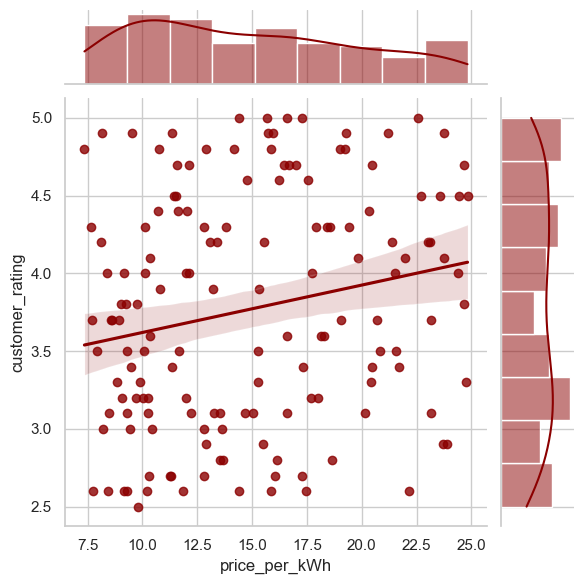

In [9]:
sns.jointplot(data=df, x="price_per_kWh", y="customer_rating", kind="reg", color="darkred")
plt.show()

##   **  6. Pairplot — Overall Feature Relationships  **

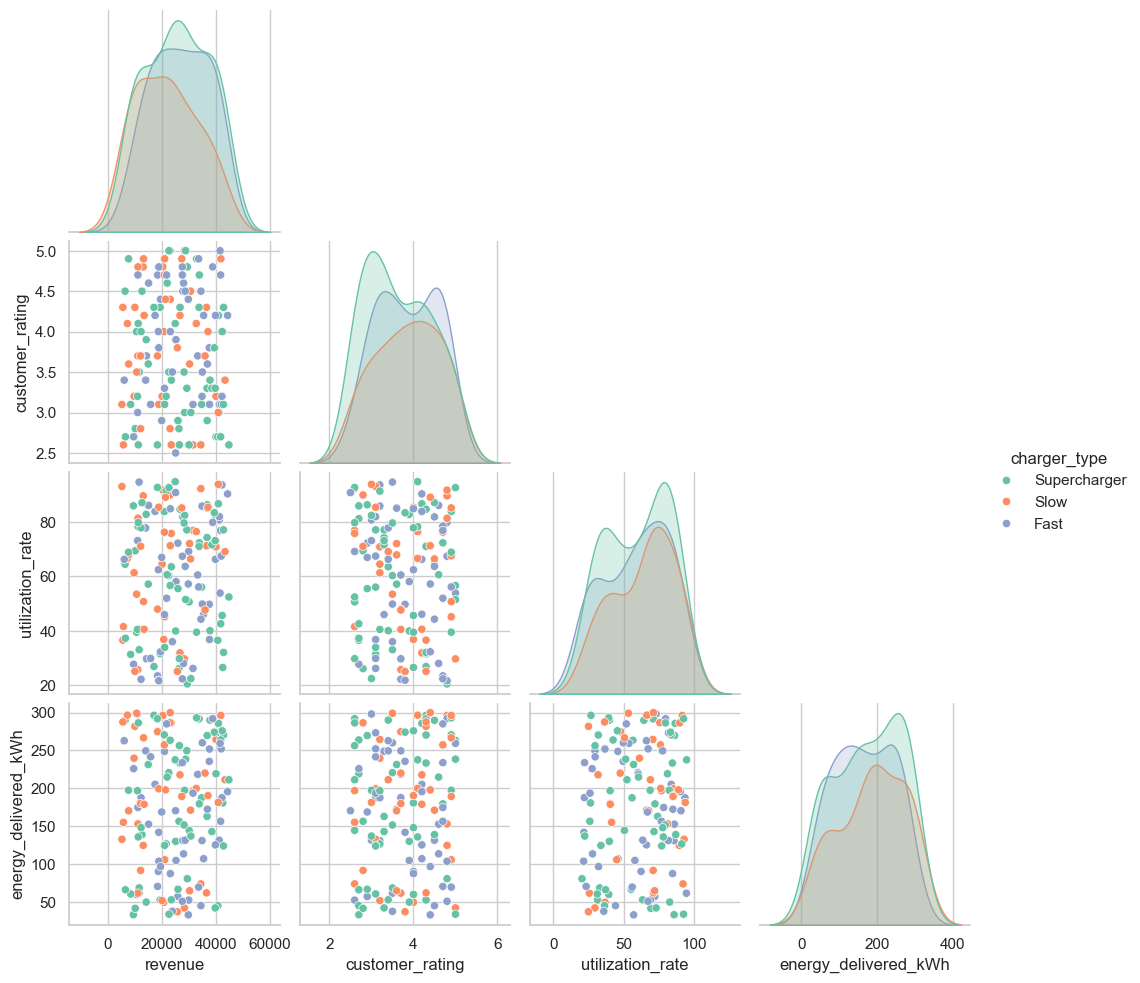

In [10]:
sns.set_style("whitegrid")

sns.pairplot(
    data=df,

    vars=["revenue","customer_rating","utilization_rate","energy_delivered_kWh"],
             hue="charger_type",
             palette="Set2",
             corner=True 
)
plt.show()

##  **  7. Revenue Distribution (Violin Plot)  **

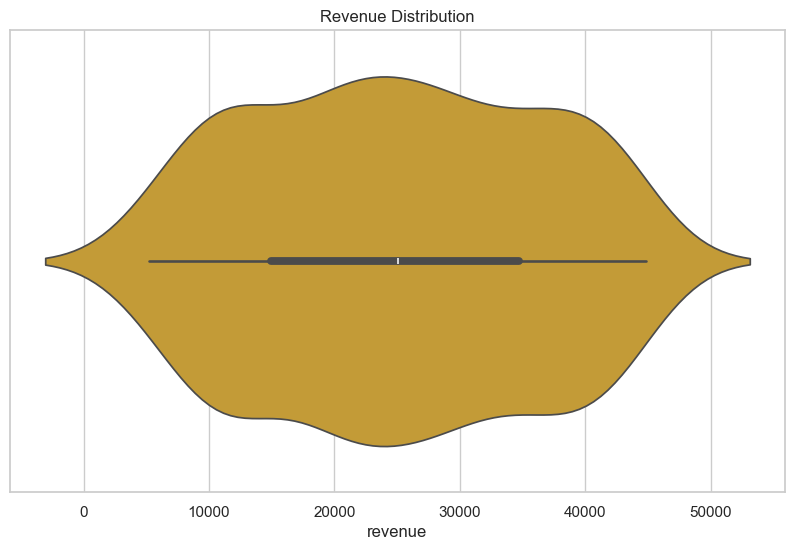

In [11]:
plt.figure()
sns.violinplot(x=df["revenue"], color="goldenrod")
plt.title("Revenue Distribution")
plt.show()


##  ** 8. Charging Time Ridge Style Plot  **

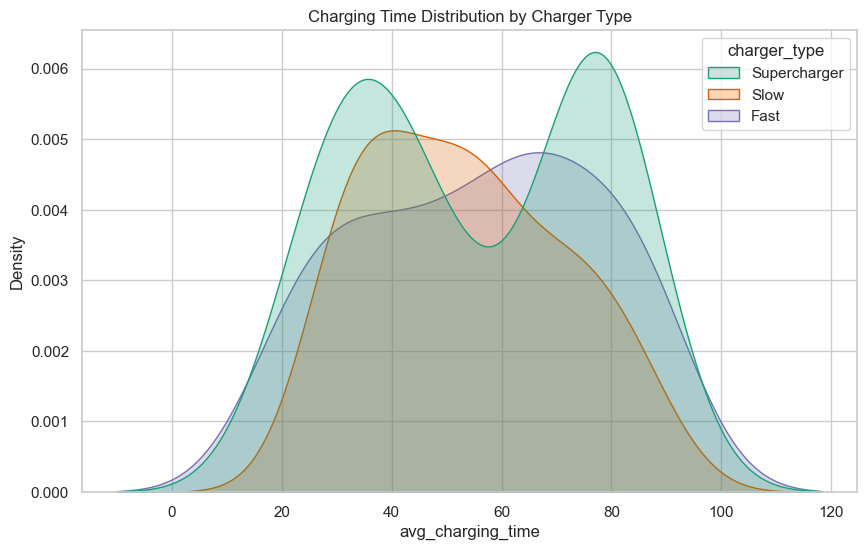

In [12]:
plt.figure()
sns.kdeplot(data=df, x="avg_charging_time", hue="charger_type", fill=True, palette="Dark2")
plt.title("Charging Time Distribution by Charger Type")
plt.show()


##   **  9. Monthly Revenue Trend (Line Plot)  **

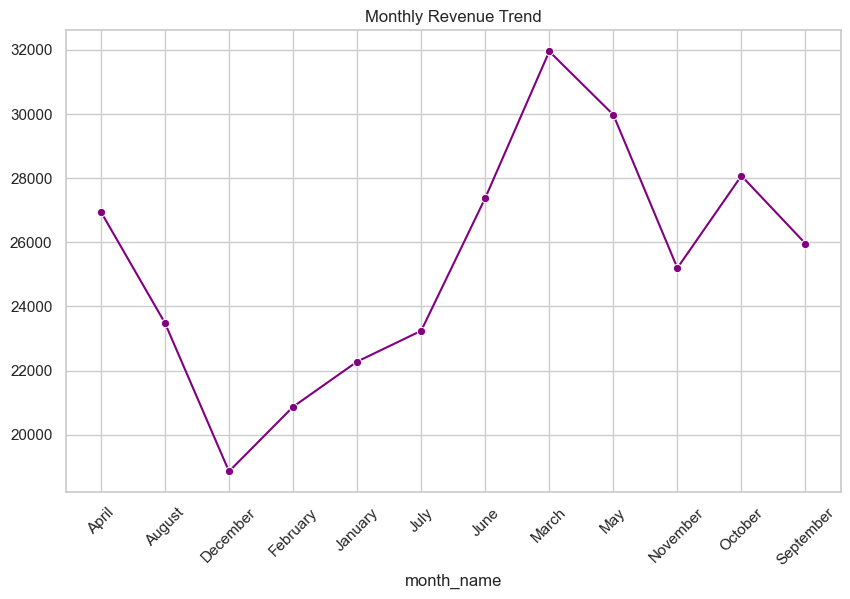

In [13]:
plt.figure()
monthly = df.groupby("month_name")["revenue"].mean()
sns.lineplot(x=monthly.index, y=monthly.values, marker="o", color="purple")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

##  **  10. Dashboard — Multiple Charts  **

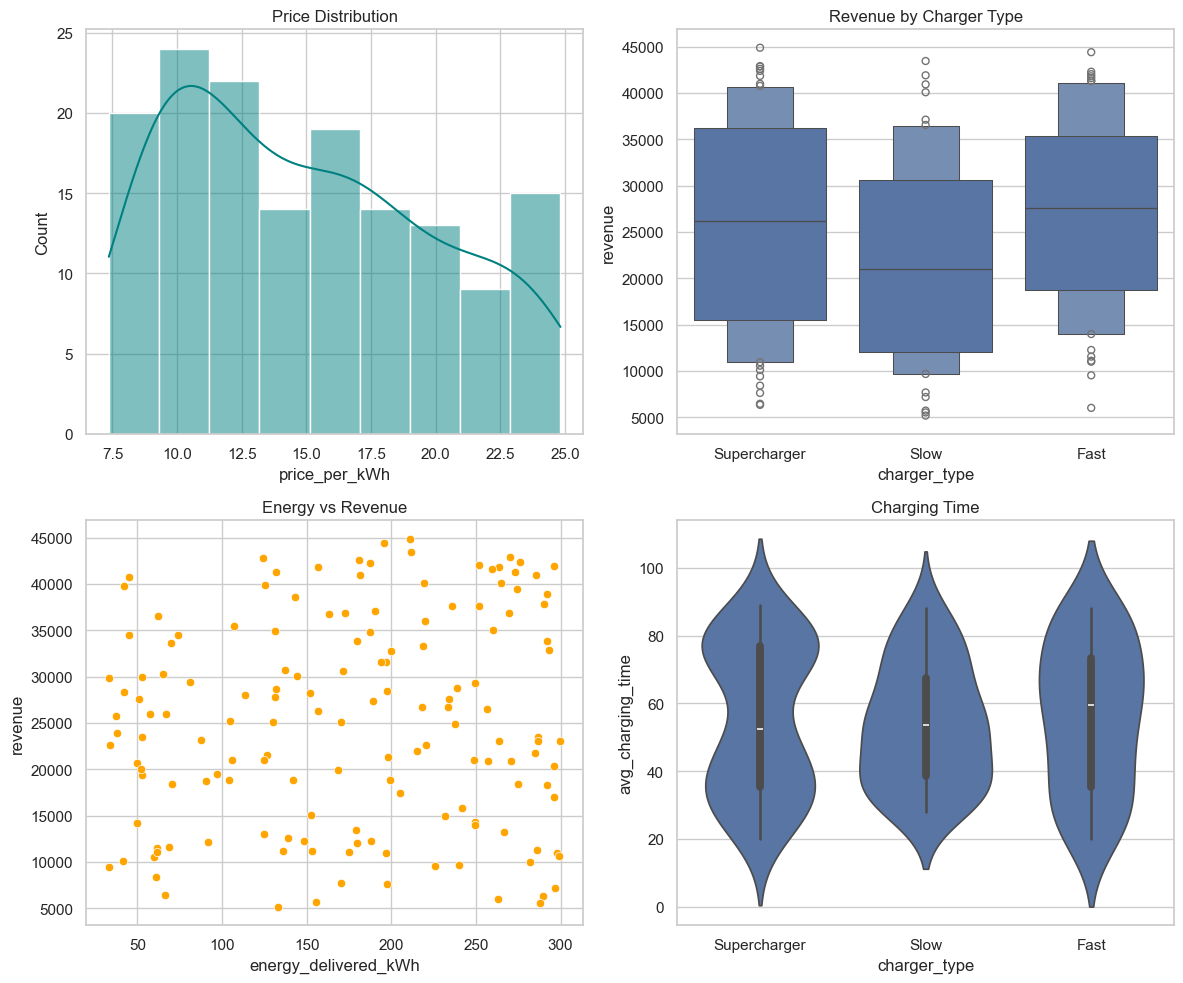

In [14]:
fig, axes = plt.subplots(2,2, figsize=(12,10))


# 1 Histogram
sns.histplot(data=df, x="price_per_kWh", kde=True, ax=axes[0,0], color="teal")
axes[0,0].set_title("Price Distribution")



# 2 Boxen plot
sns.boxenplot(data=df, x="charger_type", y="revenue", ax=axes[0,1])
axes[0,1].set_title("Revenue by Charger Type")



# 3 Scatter plot
sns.scatterplot(data=df, x="energy_delivered_kWh", y="revenue", ax=axes[1,0], color="orange")
axes[1,0].set_title("Energy vs Revenue")



# 4 Violin plot
sns.violinplot(data=df, x="charger_type", y="avg_charging_time", ax=axes[1,1])
axes[1,1].set_title("Charging Time")



plt.tight_layout()
plt.show()


## 📈 Business Insights


• Supercharger stations generate the highest revenue among all charger types.

• Cities with higher utilization rates demonstrate stronger EV adoption
  and infrastructure demand.

• Charging time differs significantly across charger types, with
  slow chargers having longer session durations.

• Customer ratings show a moderate positive relationship with revenue,
  suggesting better service quality attracts more users.

• Stations delivering higher energy per session contribute more
  to overall revenue generation.




## 📌 Final Summary


This project explored EV charging station performance using advanced
data visualization techniques.

Key outcomes:

• Identified revenue patterns across charger types  
• Analyzed charging station utilization across cities  
• Examined charging efficiency and session duration  
• Visualized relationships between energy delivery and revenue  

This project demonstrates strong exploratory data analysis
and visualization capabilities using Python and Seaborn.
